<a href="https://colab.research.google.com/github/atsuta1120/telco-churn-analysis/blob/main/%E9%9B%BB%E8%A9%B1%E5%9B%9E%E7%B7%9A%E8%A7%A3%E7%B4%84%E4%BA%88%E6%B8%AC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
import pandas as pd

df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


##カラム内容<br>
  customerID：顧客<br>
  gender：性別 Male→男、Female→女<br>
  SeniorCitizen：高齢者かどうか<br>
  Partner：顧客にパートナーがいるかどうか<br>
  Depenents：扶養家族がいるかどうか<br>
  tenure：継続期間<br>
  PhoneService：顧客が電話サービスを利用しているかどうか<br>
  MultipleLines：複数回線を契約しているかどうか<br>
  InternetService：顧客のインターネットサービスプロバイダー<br>
  OnlineSecurity：顧客がオンラインセキュリティを備えているかどうか<br>
  DeviceProtection：端末保護サービス（故障・破損時の保証サービス）に加入しているか<br>
TechSupport：テクニカルサポートサービス（トラブル時のサポート）に加入しているか<br>
StreamingTV：インターネット経由でテレビ番組を視聴するストリーミングサービスを利用しているか<br>
StreamingMovies：インターネット経由で映画を視聴するストリーミングサービスを利用しているか<br>
Contract：契約形態（例：月契約、1年契約、2年契約）<br>
PaperlessBilling：紙の請求書を使わず、オンライン請求を利用しているか<br>
PaymentMethod：料金の支払い方法（例：クレジットカード、銀行振込、電子チェックなど）<br>
MonthlyCharges：毎月の利用料金<br>
TotalCharges：これまでに支払った料金の合計額<br>
Churn：顧客がサービスを解約したかどうか（Yes＝解約、No＝継続）<br>

##EDA（=Exploratory Data Analysis）<br>
本データが分析に適しているかを下記にて調査する。

レコード数:7043,特徴量数:21

データの構造

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilli

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12392 (\N{HIRAGANA LETTER TO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


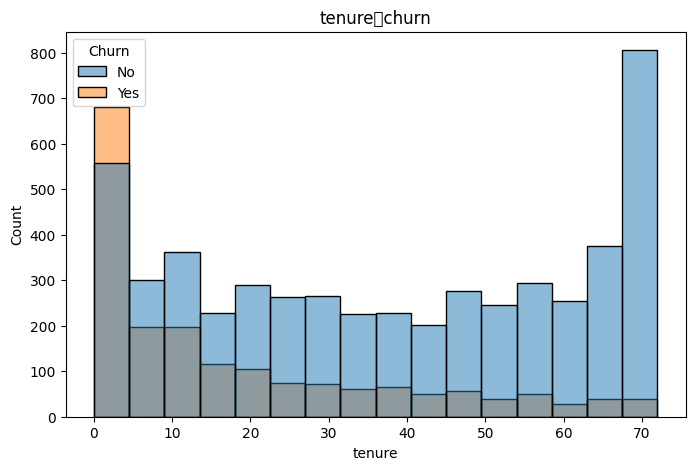

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12392 (\N{HIRAGANA LETTER TO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


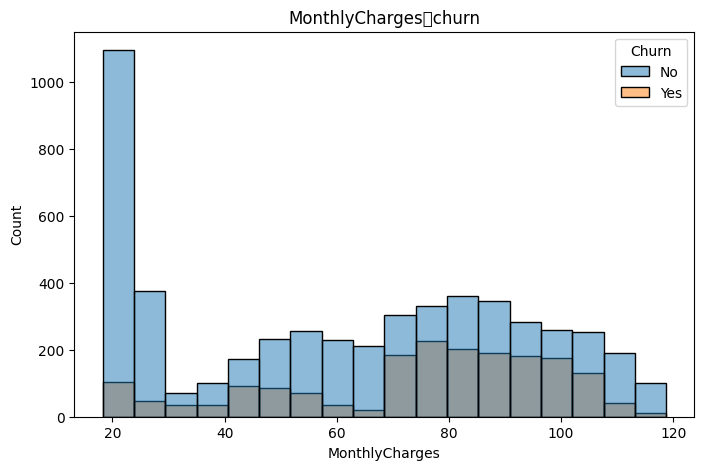

<Figure size 800x500 with 0 Axes>

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12392 (\N{HIRAGANA LETTER TO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


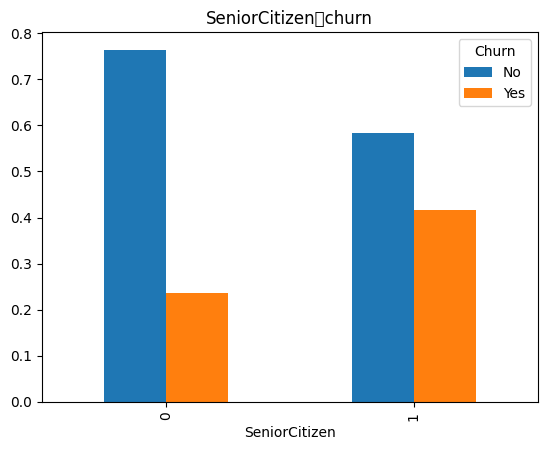

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 12392 (\N{HIRAGANA LETTER TO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


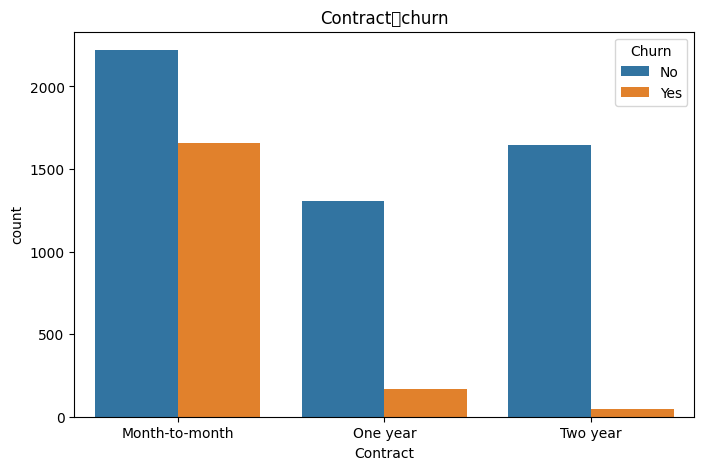

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

#レコード数と特徴量の確認
print(f"レコード数:{df.shape[0]},特徴量数:{df.shape[1]}")

#データの特徴をまとめる
print("\nデータの構造\n")
df.info()

#データのうち数値に対して分布調査
print("\n各カラム分布")
print(df.describe())

#churnのtrue or falseの割合
print("\nchurnの割合")
print(df["Churn"].value_counts(normalize=True))


print("\nカラム同士の関係性")
#churnとtenure関係値可視化
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="tenure", hue="Churn")
plt.title("tenureとchurn")
plt.show()


plt.figure(figsize=(8,5))
sns.histplot(data=df, x="MonthlyCharges", hue="Churn")
plt.title("MonthlyChargesとchurn")
plt.show()

plt.figure(figsize=(8, 5))
pd.crosstab(df["SeniorCitizen"], df["Churn"], normalize="index").plot(kind="bar")
plt.title("SeniorCitizenとchurn")
plt.show()


plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Contract", hue="Churn")
plt.title("Contractとchurn")
plt.show()







上記EDAから、レコード数が特徴量よりも多いため過学習が起きにくいデータ群と言える。<br>
また、int型やfloat型の分布については極端な外れ値がないこと、左右への偏りがないことから分析に適したデータと言える。<br>
本分析では、ロジスティック回帰を用い特徴量を変えて行い、ランダムフォレストを用い木の本数を変えて行っていく。<br>
解約予測では、解約リスクのある顧客を早期に検知し、施策対象とすることが重要である。<br>
そのため、本分析では解約顧客の見逃しを減らす目的でrecallを重視した。

In [26]:
# 分析精度の比較のために、関数を定義しrowsに分析結果を溜めていき最後に表として出力する
rows=[]
rows_threshold=[]
def evaluate(feature_set,model_name,threshold,y_test,y_pred):

  accuracy=accuracy_score(y_true=y_test,y_pred=y_pred)
  recall=recall_score(y_true=y_test,y_pred=y_pred)
  precision=precision_score(y_true=y_test,y_pred=y_pred)

  if feature_set!="":
    rows.append([feature_set,model_name,threshold,accuracy,recall,precision])
  else:
    rows_threshold.append([threshold,accuracy,recall,precision])
# 閾値の変更
def change_threshold(model,threshold,x_test,y_pred):
  y_pred_recall = model.predict_proba(x_test)[:,1]
  for i in range(len(y_pred_recall)):
    if y_pred_recall[i] >= threshold:
      y_pred_recall[i] = 1
    else:
      y_pred_recall[i] =0
  return y_pred_recall

上記のEDAしたグラフから、契約期間が長いほど解約率が低いこと、利用料金が高くなるにつれて解約率が高くなること、契約形態が長期であるほど解約率が低いことがわかった。<br>
そのため、まず初めに「tenure,MonthlyCharges,Contract」を特徴量としてchurnの分析をロジスティック回帰にて行う。<br>

In [27]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,recall_score,precision_score

# 必要カラム抽出
selected_features=df[["tenure","MonthlyCharges","Contract"]]

# 目的変数の抽出およびNo→0,Yes→1変換
y = df["Churn"].map({"No":0,"Yes":1})

# contractのダミー化
selected_features = pd.get_dummies(selected_features,drop_first=True,dtype = int)

# テスト用と学習用データに分ける
selected_features_train,selected_features_test,y_train,y_test = train_test_split(selected_features,y,test_size=0.2,random_state=42)

# 予測
lr = LogisticRegression()
lr.fit(selected_features_train,y_train)
y_pred = lr.predict(selected_features_test)

print("予測したデータの割合")
print(pd.Series(y_pred).value_counts(normalize=True))

print(lr.classes_)

y_pred_045=change_threshold(lr,0.45,selected_features_test,y_pred)
y_pred_04=change_threshold(lr,0.4,selected_features_test,y_pred)
y_pred_035=change_threshold(lr,0.35,selected_features_test,y_pred)
y_pred_03=change_threshold(lr,0.3,selected_features_test,y_pred)

evaluate("","",0.45,y_test,y_pred_045)
evaluate("","",0.4,y_test,y_pred_04)
evaluate("","",0.35,y_test,y_pred_035)
evaluate("","",0.3,y_test,y_pred_03)

rows_threshold=pd.DataFrame(rows_threshold,columns=["threshold","accuracy","recall","precision"])
print("\n閾値比較")
print(rows_threshold)


print(f"\n閾値が0.35の場合、予測した割合")
print(pd.Series(y_pred_035).value_counts(normalize = True))

evaluate("my_selected","LR",0.5,y_test,y_pred)
evaluate("my_selected","LR",0.35,y_test,y_pred_035)

予測したデータの割合
0    0.786373
1    0.213627
Name: proportion, dtype: float64
[0 1]

閾値比較
   threshold  accuracy    recall  precision
0       0.45  0.785664  0.579088   0.598338
1       0.40  0.775727  0.670241   0.564334
2       0.35  0.765082  0.723861   0.542169
3       0.30  0.763662  0.796247   0.536101

閾値が0.35の場合、予測した割合
0.0    0.646558
1.0    0.353442
Name: proportion, dtype: float64


上記閾値比較から閾値はrecallが7割り超えかつprecisionも下げ過ぎたくないため、0.35とし以下分析も同様の閾値とする。<br>

次に特徴量を全て使用し、分析を行う。<br>
加えて、どの特徴量が予測に強く寄与しているかを調べ、寄与度が高い特徴量のみを用いた分析も行う。

In [28]:
from sklearn.preprocessing import StandardScaler

# 説明変数を全て使用し予測する
x_all = df.drop(["customerID","TotalCharges","Churn"],axis = 1)

# ダミー化
x_all = pd.get_dummies(x_all,drop_first=True,dtype = int)

# テスト用と学習用データに分ける
x_all_train,x_all_test,y_train,y_test = train_test_split(x_all,y,test_size=0.2,random_state=42)

# 標準化
scaler = StandardScaler()
scaler.fit(x_all_train[["MonthlyCharges","tenure"]])
x_all_train[["MonthlyCharges","tenure"]] = scaler.transform(x_all_train[["MonthlyCharges","tenure"]])
x_all_test[["MonthlyCharges","tenure"]]= scaler.transform(x_all_test[["MonthlyCharges","tenure"]])

# 解約が少ないため、解約を重視させる
lr_all = LogisticRegression(class_weight='balanced')
lr_all.fit(x_all_train,y_train)
y_pred = lr_all.predict(x_all_test)

y_pred_recall=change_threshold(lr_all,0.35,x_all_test,y_pred)

print("\n閾値=0.4の時に予測したデータの割合")
print(pd.Series(y_pred_recall).value_counts(normalize = True))

evaluate("all_features","LR",0.5,y_test,y_pred)
evaluate("all_features","LR",0.35,y_test,y_pred_recall)

# 特徴量の係数可視化
pairs = list(zip(x_all_train.columns,lr_all.coef_[0])) #学習で使った特徴量とモデルの係数(二次元配列であるため、0番目指定)をzip化しリスト化する
pairs_sign = pd.DataFrame(pairs,columns=["feature","coef"])#DataFrame化して列名付与
pairs_abs = pd.DataFrame(pairs,columns=["feature","coef"])#DataFrame化して列名付与
pairs_abs["abs_coef"] = pairs_abs["coef"].abs()#係数を絶対値化して新しい列追加
pairs_abs = pairs_abs.drop("coef",axis = 1)
print("\n特徴量の係数可視化")
print(pairs_abs.sort_values("abs_coef",ascending = False))#係数を降順に並べ替え


閾値=0.4の時に予測したデータの割合
1.0    0.543648
0.0    0.456352
Name: proportion, dtype: float64

特徴量の係数可視化
                                  feature  abs_coef
24                      Contract_Two year  1.466170
9             InternetService_Fiber optic  1.072103
1                                  tenure  0.756315
23                      Contract_One year  0.675860
22                    StreamingMovies_Yes  0.444722
12                     OnlineSecurity_Yes  0.351796
27         PaymentMethod_Electronic check  0.346644
6                        PhoneService_Yes  0.337958
20                        StreamingTV_Yes  0.332592
25                   PaperlessBilling_Yes  0.309059
8                       MultipleLines_Yes  0.293406
18                        TechSupport_Yes  0.258352
2                          MonthlyCharges  0.255687
5                          Dependents_Yes  0.165167
0                           SeniorCitizen  0.155418
15   DeviceProtection_No internet service  0.144925
11     OnlineSecuri

0.5以上のカテゴリーを特徴量として採用し、予測を実施する。<br>
用いる特徴量は下記である。<br>
tenure,PhoneService,InternetService,Contract

In [29]:
# 説明変数を抽出し、テスト用と学習用データに分ける
x_over0_5=x_all[["tenure","PhoneService_Yes","Contract_One year","Contract_Two year","InternetService_Fiber optic","InternetService_No"]]
x_over0_5_train,x_over0_5_test,y_train,y_test = train_test_split(x_over0_5,y,test_size=0.2,random_state=42)
scaler = StandardScaler()

# 標準化
scaler.fit(x_over0_5_train[["tenure"]])
x_over0_5_train[["tenure"]] = scaler.transform(x_over0_5_train[["tenure"]])
x_over0_5_test[["tenure"]]= scaler.transform(x_over0_5_test[["tenure"]])

# 解約が少ないため、解約を重視させる
lr_over_0_5 = LogisticRegression(class_weight='balanced')
lr_over_0_5.fit(x_over0_5_train,y_train)
y_pred = lr_over_0_5.predict(x_over0_5_test)

y_pred_recall=change_threshold(lr_over_0_5,0.35,x_over0_5_test,y_pred)

print("\n閾値=0.4の時に予測したデータの割合")
print(pd.Series(y_pred_recall).value_counts(normalize = True))

evaluate("coef_over_0.5","LR",0.5,y_test,y_pred)
evaluate("coef_over_0.5","LR",0.35,y_test,y_pred_recall)



閾値=0.4の時に予測したデータの割合
1.0    0.569908
0.0    0.430092
Name: proportion, dtype: float64


次にランダムフォレストにて分析を行う。<br>
本数は100本とする。

In [30]:
from sklearn.ensemble import RandomForestClassifier

# 特徴量選定
# ランダムフォレストのため、意味が被るもの、意味のないもの、目的変数以外を使用する
x_rf = df.drop(["customerID","TotalCharges","Churn"],axis = 1)
x_rf = pd.get_dummies(x_all,drop_first=True,dtype = int)

# 説明変数を抽出し、テスト用と学習用データに分ける
x_rf_train,x_rf_test,y_train,y_test = train_test_split(x_rf,y,test_size=0.2,random_state=42)

# 木の本数を100本とし、解約を重視させる
rf = RandomForestClassifier(n_estimators=100,class_weight="balanced")
rf.fit(x_rf_train,y_train)
y_pred = rf.predict(x_rf_test)
print(pd.Series(y_pred).value_counts(normalize=True))

y_pred_k=change_threshold(rf,0.35,x_rf_test,y_pred)

print(pd.Series(y_pred_k).value_counts(normalize=True))

evaluate("tree_100","RF",0.5,y_test,y_pred)
evaluate("tree_100","RF",0.3,y_test,y_pred_k)

0    0.82044
1    0.17956
Name: proportion, dtype: float64
0.0    0.682044
1.0    0.317956
Name: proportion, dtype: float64


下記のランダムフォレストの本数は300本とする。

In [31]:
rf_300 = RandomForestClassifier(n_estimators=300,class_weight="balanced")
rf_300.fit(x_rf_train,y_train)
y_pred_300 = rf_300.predict(x_rf_test)
print(pd.Series(y_pred).value_counts(normalize=True))

y_pred_k=change_threshold(rf_300,0.35,x_rf_test,y_pred)

print(pd.Series(y_pred_k).value_counts(normalize=True))

evaluate("tree_300","RF",0.5,y_test,y_pred_300)
evaluate("tree_300","RF",0.35,y_test,y_pred_k)

0    0.82044
1    0.17956
Name: proportion, dtype: float64
0.0    0.679915
1.0    0.320085
Name: proportion, dtype: float64


下記のランダムフォレストの本数は50本とする。

In [32]:
rf_50= RandomForestClassifier(n_estimators=50,class_weight="balanced")
rf_50.fit(x_rf_train,y_train)
y_pred_50= rf_50.predict(x_rf_test)
print(pd.Series(y_pred_50).value_counts(normalize=True))

y_pred_k=change_threshold(rf_50,0.35,x_rf_test,y_pred)

print(pd.Series(y_pred_k).value_counts(normalize=True))

evaluate("tree_50","RF",0.5,y_test,y_pred_50)
evaluate("tree_50","RF",0.35,y_test,y_pred_k)

0    0.821859
1    0.178141
Name: proportion, dtype: float64
0.0    0.687722
1.0    0.312278
Name: proportion, dtype: float64


In [33]:
pairs_rf=list(zip(x_rf_train.columns,rf.feature_importances_))
pairs_rf=pd.DataFrame(pairs_rf,columns=["feature","coef"])
pairs_rf["abs_coef"]=pairs_rf["coef"].abs()
pairs_rf=pairs_rf.drop("coef",axis=1)
print(f"ランダムフォレストの特徴量重要度(本数100)")
print(pairs_rf.sort_values("abs_coef",ascending=False))
print(f"\nロジスティック回帰の絶対値係数")
print(pairs_abs.sort_values("abs_coef",ascending = False))#係数を降順に並べ替え
print(f"\nロジスティック回帰の符号付き係数")
print(pairs_sign.sort_values("coef",ascending = False))#係数を降順に並べ替え

ランダムフォレストの特徴量重要度(本数100)
                                  feature  abs_coef
1                                  tenure  0.225224
2                          MonthlyCharges  0.199997
24                      Contract_Two year  0.073353
27         PaymentMethod_Electronic check  0.040730
9             InternetService_Fiber optic  0.039906
23                      Contract_One year  0.036355
3                             gender_Male  0.031514
12                     OnlineSecurity_Yes  0.030514
18                        TechSupport_Yes  0.027488
25                   PaperlessBilling_Yes  0.027358
4                             Partner_Yes  0.026119
14                       OnlineBackup_Yes  0.024525
5                          Dependents_Yes  0.022834
8                       MultipleLines_Yes  0.021397
16                   DeviceProtection_Yes  0.021163
22                    StreamingMovies_Yes  0.020461
0                           SeniorCitizen  0.020021
20                        StreamingTV_Ye

In [34]:
print("予測精度比較")
rows=pd.DataFrame(rows,columns=["feature_set","model","threshold","accuracy","recall","precision"])
print(rows.sort_values("recall",ascending=False))

予測精度比較
      feature_set model  threshold  accuracy    recall  precision
5   coef_over_0.5    LR       0.35  0.657913  0.930295   0.432130
3    all_features    LR       0.35  0.681334  0.924933   0.450392
4   coef_over_0.5    LR       0.50  0.740241  0.831099   0.505710
2    all_features    LR       0.50  0.755855  0.823056   0.524786
1     my_selected    LR       0.35  0.765082  0.723861   0.542169
9        tree_300    RF       0.35  0.779986  0.689008   0.569845
7        tree_100    RF       0.30  0.779276  0.683646   0.569196
11        tree_50    RF       0.35  0.777857  0.670241   0.568182
0     my_selected    LR       0.50  0.802697  0.530831   0.657807
8        tree_300    RF       0.50  0.792761  0.463807   0.652830
6        tree_100    RF       0.50  0.794180  0.450402   0.664032
10        tree_50    RF       0.50  0.794180  0.447721   0.665339


ロジスティック回帰の符号付き係数から、InternetServiceがFiber opticである顧客や、ストリーミングTV・映画を利用している顧客は解約しやすい傾向が見られた。一方で、長期契約、継続期間の長さ、電話サービスやオンラインセキュリティの利用は、解約しにくさと関係していることが確認できた。<br>

これらの結果から、解約率を下げる施策として、オンラインセキュリティの加入促進や、短期契約者に対する長期契約への移行提案が有効である可能性がある。具体的には、オンラインセキュリティの案内、セット契約による軽微な割引、ポイント付与、長期契約への移行特典などが考えられる。<br>

ただし、各モデルのprecisionは約40〜60%であり、解約リスクありと予測された顧客の中にも実際には解約しない顧客が多く含まれる。そのため、大幅な割引や高額ポイント付与のような高コスト施策を一律に実施するのは適切ではない。まずはメール案内やプラン見直し提案などの低コスト施策を中心に実施し、高コスト施策は予測確率が特に高い顧客や、Month-to-month契約・継続期間が短い・月額料金が高いなど複数のリスク条件を満たす顧客に限定する必要がある。<br>

上記の予測精度比較から特徴量を全て使用するよりも、寄与度が高い特徴量を用いた分析の方が精度が高いことがわかる。<br>
これは、特徴量を全て使用することで予測への寄与度が低い特徴量がノイズとなり、モデルの汎化性能が下がったためと考える。